# lwtnn vs ONNX Runtime — Inference Benchmark

Compares lwtnn C++ inference against ONNX Runtime C++ on two network architectures:

| | Architecture | Type |
|---|---|---|
| **GRU** | Masking → GRU(25) → MaxoutDense(64,5) → Dense(64) → Highway(64) → Dense(4) → Softmax | Sequence |
| **MLP** | 60 → 128 → 64 → 32 → 16 → 8, tanh | Feedforward |

Each lwtnn backend is run at both **float64** (default) and **float32** (via `generic::LightweightNeuralNetwork<float>`) so precision is matched against ORT (which uses float32).

In [1]:
import json
import os
import subprocess
import sys
import tarfile
import tempfile
import urllib.request
from pathlib import Path

import h5py
import numpy as np
import torch
import torch.nn as nn
import onnx
from onnx import numpy_helper, helper, TensorProto
import onnxruntime as ort
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

REPO_ROOT = Path("../").resolve()
BUILD_DIR = REPO_ROOT / "build"
CONVERTER  = REPO_ROOT / "converters" / "keras2json.py"

LWTNN_RNN_BENCH     = BUILD_DIR / "bin" / "lwtnn-bench-inference"
LWTNN_RNN_F32_BENCH = BUILD_DIR / "bin" / "lwtnn-bench-inference-f32"
LWTNN_MLP_BENCH     = BUILD_DIR / "bin" / "lwtnn-bench-mlp"
LWTNN_MLP_F32_BENCH = BUILD_DIR / "bin" / "lwtnn-bench-mlp-f32"
ORT_BENCH           = BUILD_DIR / "bin" / "ort-bench-inference"

for b in [LWTNN_RNN_BENCH, LWTNN_RNN_F32_BENCH,
          LWTNN_MLP_BENCH, LWTNN_MLP_F32_BENCH, ORT_BENCH]:
    assert b.exists(), f"Binary not found: {b} — run: cmake --build {BUILD_DIR}"

print("All binaries found.")

All binaries found.


In [2]:
# ── configuration ─────────────────────────────────────────────────────────────
N_INFERENCES = 2000   # per benchmark run
N_PATTERNS   = 20     # GRU sequence length (matches lwtnn-test-rnn default)
GRU_TEST_URL = "https://github.com/lwtnn/lwtnn-test-data/raw/v2.1/GRU.tgz"

# MLP architecture
MLP_LAYERS = [60, 128, 64, 32, 16, 8]
MLP_ACT    = "tanh"

## Shared utilities

In [3]:
def parse_bench_kv(text: str) -> dict:
    """Parse key=value lines from a C++ benchmark binary."""
    kv = {}
    for line in text.strip().splitlines():
        if "=" not in line:
            continue
        k, _, v = line.partition("=")
        kv[k.strip()] = v.strip()
    return kv


def run_bin(*args) -> dict:
    """Run a benchmark binary and return parsed key=value dict."""
    result = subprocess.run(
        [str(a) for a in args],
        capture_output=True, text=True, check=True,
    )
    return parse_bench_kv(result.stdout)


TIMING_KEYS = [
    ("inference_mean_us",   "Mean (µs)"),
    ("inference_min_us",    "Min (µs)"),
    ("inference_median_us", "Median (µs)"),
    ("inference_p99_us",    "p99 (µs)"),
    ("inference_max_us",    "Max (µs)"),
    ("peak_rss_kb",         "Peak RSS (MB)"),
]


def bench_to_df(cols: dict, *, rss_to_mb=True) -> pd.DataFrame:
    """
    cols: {column_label: kv_dict}  e.g. {"lwtnn f64": {...}, "ORT": {...}}
    Returns a DataFrame with metrics as rows and backends as columns.
    """
    rows = []
    for key, label in TIMING_KEYS:
        row = {"Metric": label}
        for col_name, kv in cols.items():
            val = float(kv.get(key, float("nan")))
            if rss_to_mb and key == "peak_rss_kb":
                val /= 1024.0
            row[col_name] = val
        rows.append(row)
    return pd.DataFrame(rows).set_index("Metric")


def show_bench_df(df: pd.DataFrame, baseline_col: str = None):
    """Display benchmark DataFrame with optional ratio columns vs baseline."""
    display_df = df.copy()
    if baseline_col and baseline_col in df.columns:
        for col in df.columns:
            if col != baseline_col:
                display_df[f"{col} / {baseline_col}"] = (
                    df[col] / df[baseline_col]).map("{:.2f}×".format)
    display(display_df.style
            .format(lambda v: f"{v:.3f}" if isinstance(v, float) else v)
            .set_caption(f"Timing (µs) and peak RSS (MB) · {N_INFERENCES} inferences")
            .highlight_min(axis=1, subset=list(df.columns), props="font-weight:bold"))


def plot_latency_bar(df: pd.DataFrame, title: str, metric="Mean (µs)",
                     colors=None):
    """Bar chart comparing mean latency across backends."""
    row = df.loc[metric]
    if colors is None:
        palette = ["#3b82f6", "#93c5fd", "#ef4444", "#22c55e", "#f59e0b"]
        colors = palette[:len(row)]
    fig, ax = plt.subplots(figsize=(7, 3.8))
    bars = ax.bar(row.index, row.values, color=colors, width=0.5, edgecolor="white")
    ax.bar_label(bars, fmt="%.1f µs", padding=3, fontsize=9)
    ax.set_ylabel("Latency (µs)", fontsize=10)
    ax.set_title(title, fontsize=11, pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

---
## Part 1 — GRU network

Architecture: **Masking → GRU(25) → MaxoutDense(64, 5 pieces) → Dense(64) → Highway(64) → Dense(4) → Softmax**

Input: 19 features × 20 time-steps.

### 1.1  Download test data and convert to lwtnn JSON

In [4]:
gru_tmpdir = Path(tempfile.mkdtemp(prefix="lwtnn_gru_"))

print("Downloading GRU test data …")
tgz_path = gru_tmpdir / "GRU.tgz"
urllib.request.urlretrieve(GRU_TEST_URL, tgz_path)
with tarfile.open(tgz_path) as tar:
    tar.extractall(gru_tmpdir)

arch_json  = gru_tmpdir / "GRU.json"
variables  = gru_tmpdir / "variables.json"
h5_weights = gru_tmpdir / "weights" / "GRU_weights.h5"

with open(variables) as f:
    var_cfg = json.load(f)
class_labels = var_cfg["class_labels"]
n_gru_inputs = len(var_cfg["inputs"])
print(f"  {n_gru_inputs} input features, classes: {class_labels}")

print("Converting Keras model → lwtnn JSON …")
lwtnn_gru_json = str(gru_tmpdir / "lwtnn_model.json")
with open(lwtnn_gru_json, "w") as out_f:
    subprocess.run(
        [sys.executable, str(CONVERTER), str(arch_json), str(variables), str(h5_weights)],
        stdout=out_f, stderr=subprocess.DEVNULL, check=True,
    )
print("  done.")

  19 input features, classes: ['pu', 'pc', 'pb', 'ptau']
Converting Keras model → lwtnn JSON …


  done.


### 1.2  PyTorch reference model (Theano GRU conventions)

In [5]:
def hard_sigmoid(x):
    return torch.clamp(0.2 * x + 0.5, 0.0, 1.0)

class TheanoGRU(nn.Module):
    def __init__(self, W_z, W_r, W_h, U_z, U_r, U_h, b_z, b_r, b_h):
        super().__init__()
        for name, arr in [("W_z",W_z),("W_r",W_r),("W_h",W_h),
                          ("U_z",U_z),("U_r",U_r),("U_h",U_h),
                          ("b_z",b_z),("b_r",b_r),("b_h",b_h)]:
            self.register_buffer(name, torch.tensor(arr, dtype=torch.float32))
        self.hidden_size = W_z.shape[1]
    def forward(self, x):
        batch, seq_len, _ = x.shape
        h = torch.zeros(batch, self.hidden_size, dtype=x.dtype)
        for t in range(seq_len):
            xt = x[:, t, :]
            z  = hard_sigmoid(xt @ self.W_z + h @ self.U_z + self.b_z)
            r  = hard_sigmoid(xt @ self.W_r + h @ self.U_r + self.b_r)
            hh = torch.tanh(xt @ self.W_h + (r * h) @ self.U_h + self.b_h)
            h  = z * h + (1 - z) * hh
        return h

class MaxoutDense(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))
        self.register_buffer("b", torch.tensor(b, dtype=torch.float32))
    def forward(self, x):
        return (torch.einsum("bi,kio->bko", x, self.W) + self.b).max(dim=1).values

class Highway(nn.Module):
    def __init__(self, W, b, W_carry, b_carry):
        super().__init__()
        for name, arr in [("W",W),("b",b),("W_carry",W_carry),("b_carry",b_carry)]:
            self.register_buffer(name, torch.tensor(arr, dtype=torch.float32))
    def forward(self, x):
        t = torch.sigmoid(x @ self.W_carry + self.b_carry)
        return t * torch.relu(x @ self.W + self.b) + (1 - t) * x

class LinearLayer(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))
        self.register_buffer("b", torch.tensor(b, dtype=torch.float32))
    def forward(self, x): return x @ self.W + self.b

class GRUNet(nn.Module):
    def __init__(self, h5_path):
        super().__init__()
        with h5py.File(h5_path, "r") as f:
            def w(k): return np.array(f[k])
            self.gru     = TheanoGRU(w("gru_1/gru_1_W_z"), w("gru_1/gru_1_W_r"), w("gru_1/gru_1_W_h"),
                                     w("gru_1/gru_1_U_z"), w("gru_1/gru_1_U_r"), w("gru_1/gru_1_U_h"),
                                     w("gru_1/gru_1_b_z"), w("gru_1/gru_1_b_r"), w("gru_1/gru_1_b_h"))
            self.maxout  = MaxoutDense(w("maxoutdense_1/maxoutdense_1_W"), w("maxoutdense_1/maxoutdense_1_b"))
            self.dense1  = LinearLayer(w("dense_1/dense_1_W"), w("dense_1/dense_1_b"))
            self.highway = Highway(w("highway_1/highway_1_W"), w("highway_1/highway_1_b"),
                                   w("highway_1/highway_1_W_carry"), w("highway_1/highway_1_b_carry"))
            self.dense2  = LinearLayer(w("dense_2/dense_2_W"), w("dense_2/dense_2_b"))
    def forward(self, x):
        return torch.softmax(self.dense2(self.highway(self.dense1(self.maxout(self.gru(x))))), dim=-1)

def make_gru_input(n_inputs, n_patterns):
    x = np.linspace(-1.0, 1.0, n_inputs)
    y = np.linspace(-1.0, 1.0, n_patterns)
    return torch.tensor((x[:, None] * y[None, :]).T[None], dtype=torch.float32)

gru_model = GRUNet(str(h5_weights)).eval()
gru_input  = make_gru_input(n_gru_inputs, N_PATTERNS)
with torch.no_grad():
    gru_pt_out = gru_model(gru_input).squeeze(0).numpy()

print("PyTorch GRU output:")
display(pd.DataFrame([dict(zip(class_labels, gru_pt_out))]).style.format("{:.6f}"))

PyTorch GRU output:


,pu,pc,pb,ptau
0,0.016547,0.003917,0.940662,0.038875


### 1.3  Build ONNX models (unrolled + native GRU op)

In [6]:
gru_onnx_unrolled = str(gru_tmpdir / "gru_unrolled.onnx")
torch.onnx.export(
    gru_model, gru_input, gru_onnx_unrolled,
    input_names=["normalized_input"], output_names=["class_probs"],
    dynamic_axes={"normalized_input": {0: "batch", 1: "seq_len"}},
    opset_version=17,
)
n_unrolled = len(onnx.load(gru_onnx_unrolled).graph.node)

def build_native_gru_onnx(h5_path, onnx_path):
    with h5py.File(h5_path) as f:
        def w(k): return np.array(f[k], dtype=np.float32)
        W_z,W_r,W_h = w("gru_1/gru_1_W_z"),w("gru_1/gru_1_W_r"),w("gru_1/gru_1_W_h")
        U_z,U_r,U_h = w("gru_1/gru_1_U_z"),w("gru_1/gru_1_U_r"),w("gru_1/gru_1_U_h")
        b_z,b_r,b_h = w("gru_1/gru_1_b_z"),w("gru_1/gru_1_b_r"),w("gru_1/gru_1_b_h")
        W_mo = w("maxoutdense_1/maxoutdense_1_W"); b_mo = w("maxoutdense_1/maxoutdense_1_b")
        W_d1,b_d1 = w("dense_1/dense_1_W"),w("dense_1/dense_1_b")
        W_hw,b_hw = w("highway_1/highway_1_W"),w("highway_1/highway_1_b")
        W_hc,b_hc = w("highway_1/highway_1_W_carry"),w("highway_1/highway_1_b_carry")
        W_d2,b_d2 = w("dense_2/dense_2_W"),w("dense_2/dense_2_b")
    hidden=W_z.shape[1]; n_in=W_z.shape[0]; nb_feat=W_mo.shape[0]; nb_out=W_mo.shape[2]
    W_gru = np.concatenate([W_z.T,W_r.T,W_h.T],axis=0)[None]
    R_gru = np.concatenate([U_z.T,U_r.T,U_h.T],axis=0)[None]
    B_gru = np.concatenate([b_z,b_r,b_h,np.zeros(3*hidden,dtype=np.float32)])[None]
    W_mo_flat = W_mo.transpose(1,0,2).reshape(hidden,nb_feat*nb_out).astype(np.float32)
    def init(name,arr): return numpy_helper.from_array(np.ascontiguousarray(arr),name=name)
    inits=[init("gru_W",W_gru),init("gru_R",R_gru),init("gru_B",B_gru),
           init("mo_W",W_mo_flat),init("mo_b",b_mo),
           init("d1_W",W_d1),init("d1_b",b_d1),
           init("hw_W",W_hw),init("hw_b",b_hw),init("hw_Wc",W_hc),init("hw_bc",b_hc),
           init("d2_W",W_d2),init("d2_b",b_d2),
           init("ones_1",np.ones(1,dtype=np.float32)),
           init("sq_axes",np.array([0],dtype=np.int64)),
           init("mo_out_shape",np.array([1,nb_feat,nb_out],dtype=np.int64))]
    N=helper.make_node
    nodes=[N("Transpose",["x"],["x_seq"],perm=[1,0,2]),
           helper.make_node("GRU",["x_seq","gru_W","gru_R","gru_B"],["","gru_Yh"],
                            hidden_size=hidden,direction="forward",
                            activations=["HardSigmoid","Tanh"],
                            activation_alpha=[0.2,0.0],activation_beta=[0.5,0.0]),
           N("Squeeze",["gru_Yh","sq_axes"],["h0"]),
           N("MatMul",["h0","mo_W"],["mo_mm"]),N("Reshape",["mo_mm","mo_out_shape"],["mo_rs"]),
           N("Add",["mo_rs","mo_b"],["mo_add"]),N("ReduceMax",["mo_add"],["h1"],axes=[1],keepdims=0),
           N("MatMul",["h1","d1_W"],["d1_mm"]),N("Add",["d1_mm","d1_b"],["h2"]),
           N("MatMul",["h2","hw_Wc"],["hc_mm"]),N("Add",["hc_mm","hw_bc"],["hc_pre"]),
           N("Sigmoid",["hc_pre"],["t"]),
           N("MatMul",["h2","hw_W"],["hw_mm"]),N("Add",["hw_mm","hw_b"],["hw_pre"]),
           N("Relu",["hw_pre"],["h_xform"]),N("Mul",["t","h_xform"],["carry"]),
           N("Sub",["ones_1","t"],["one_mt"]),N("Mul",["one_mt","h2"],["pass"]),
           N("Add",["carry","pass"],["h3"]),
           N("MatMul",["h3","d2_W"],["d2_mm"]),N("Add",["d2_mm","d2_b"],["logits"]),
           N("Softmax",["logits"],["class_probs"],axis=-1)]
    x_info=helper.make_tensor_value_info("x",TensorProto.FLOAT,[1,None,n_in])
    out_info=helper.make_tensor_value_info("class_probs",TensorProto.FLOAT,[1,4])
    graph=helper.make_graph(nodes,"gru_native_op",[x_info],[out_info],inits)
    m=helper.make_model(graph,opset_imports=[helper.make_opsetid("",17)]); m.ir_version=8
    onnx.checker.check_model(m); onnx.save(m,onnx_path)

gru_onnx_native = str(gru_tmpdir / "gru_native.onnx")
build_native_gru_onnx(str(h5_weights), gru_onnx_native)
n_native = len(onnx.load(gru_onnx_native).graph.node)
print(f"ONNX graph size:  unrolled = {n_unrolled} nodes  |  native GRU op = {n_native} nodes")

ONNX graph size:  unrolled = 727 nodes  |  native GRU op = 22 nodes


### 1.4  Output correctness

In [7]:
lwtnn_rnn_result = subprocess.run(
    [str(BUILD_DIR / "bin" / "lwtnn-test-rnn"), lwtnn_gru_json],
    capture_output=True, text=True, check=True)
lwtnn_gru_out = {k: float(v) for k, v in
    (line.split() for line in lwtnn_rnn_result.stdout.strip().splitlines())}

sess_u = ort.InferenceSession(gru_onnx_unrolled, providers=["CPUExecutionProvider"])
ort_u  = sess_u.run(["class_probs"], {"normalized_input": gru_input.numpy()})[0].squeeze(0)
sess_n = ort.InferenceSession(gru_onnx_native, providers=["CPUExecutionProvider"])
ort_n  = sess_n.run(["class_probs"], {"x": gru_input.numpy()})[0].squeeze(0)

rows = []
for i, label in enumerate(class_labels):
    lv, pv, ov_u, ov_n = lwtnn_gru_out[label], float(gru_pt_out[i]), float(ort_u[i]), float(ort_n[i])
    rows.append({"Class": label, "lwtnn (f64)": lv, "PyTorch": pv,
                 "ORT unrolled": ov_u, "ORT native": ov_n,
                 "|lwtnn−PyTorch|": abs(lv-pv), "|lwtnn−native|": abs(lv-ov_n)})

display(pd.DataFrame(rows).set_index("Class").style
    .format({"lwtnn (f64)":"{:.7f}","PyTorch":"{:.7f}",
             "ORT unrolled":"{:.7f}","ORT native":"{:.7f}",
             "|lwtnn−PyTorch|":"{:.2e}","|lwtnn−native|":"{:.2e}"})
    .set_caption("GRU: output comparison")
    .highlight_max(subset=["|lwtnn−PyTorch|","|lwtnn−native|"],
                   props="background-color:#fee2e2"))

,lwtnn (f64),PyTorch,ORT unrolled,ORT native,|lwtnn−PyTorch|,|lwtnn−native|
Class,,,,,,
pu,0.0165469,0.0165469,0.0165469,0.0165470,3.18e-09,5.35e-08
pc,0.0039168,0.0039168,0.0039168,0.0039168,3.26e-09,4.67e-10
pb,0.9406620,0.9406618,0.9406617,0.9406615,1.52e-07,4.50e-07
ptau,0.0388746,0.0388745,0.0388746,0.0388747,7.07e-08,8.20e-08


### 1.5  C++ benchmark: lwtnn f64, lwtnn f32, ORT unrolled, ORT native GRU

In [8]:
print(f"Running {N_INFERENCES} inferences per backend …")

gru_lwtnn_f64_kv = run_bin(LWTNN_RNN_BENCH, lwtnn_gru_json, "--n-inferences", N_INFERENCES)
print("  lwtnn f64 done")

gru_lwtnn_f32_kv = run_bin(LWTNN_RNN_F32_BENCH, lwtnn_gru_json, "--n-inferences", N_INFERENCES)
print("  lwtnn f32 done")

gru_ort_unrolled_kv = run_bin(
    ORT_BENCH, gru_onnx_unrolled,
    "--n-inferences", N_INFERENCES, "--n-inputs", n_gru_inputs, "--n-timesteps", N_PATTERNS)
print("  ORT unrolled done")

gru_ort_native_kv = run_bin(
    ORT_BENCH, gru_onnx_native,
    "--n-inferences", N_INFERENCES, "--n-inputs", n_gru_inputs, "--n-timesteps", N_PATTERNS)
print("  ORT native GRU done")

gru_bench_df = bench_to_df({
    "lwtnn f64":      gru_lwtnn_f64_kv,
    "lwtnn f32":      gru_lwtnn_f32_kv,
    "ORT unrolled":   gru_ort_unrolled_kv,
    "ORT native GRU": gru_ort_native_kv,
})
show_bench_df(gru_bench_df, baseline_col="lwtnn f64")

Running 2000 inferences per backend …
  lwtnn f64 done


  lwtnn f32 done


  ORT unrolled done
  ORT native GRU done


,lwtnn f64,lwtnn f32,ORT unrolled,ORT native GRU,lwtnn f32 / lwtnn f64,ORT unrolled / lwtnn f64,ORT native GRU / lwtnn f64
Metric,,,,,,,
Mean (µs),46.989,30.717,245.428,30.260,0.65×,5.22×,0.64×
Min (µs),45.060,28.099,224.973,28.359,0.62×,4.99×,0.63×
Median (µs),46.650,30.820,246.274,30.442,0.66×,5.28×,0.65×
p99 (µs),52.149,33.668,271.557,40.899,0.65×,5.21×,0.78×
Max (µs),65.043,46.724,1093.345,49.883,0.72×,16.81×,0.77×
Peak RSS (MB),15.062,15.070,35.773,33.922,1.00×,2.38×,2.25×


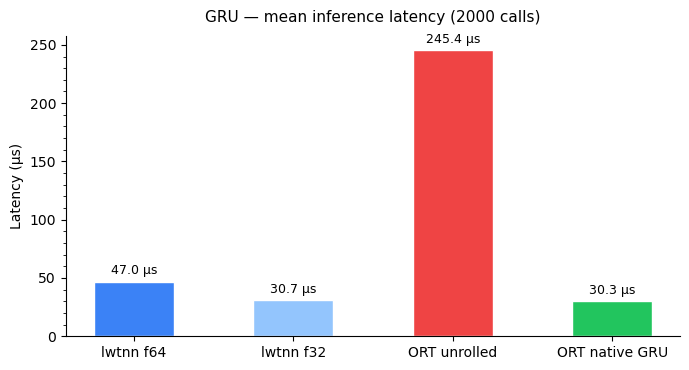

In [9]:
plot_latency_bar(
    gru_bench_df,
    f"GRU — mean inference latency ({N_INFERENCES} calls)",
    colors=["#3b82f6", "#93c5fd", "#ef4444", "#22c55e"],
)

---
## Part 2 — MLP network

Architecture: **60 → 128 → 64 → 32 → 16 → 8, tanh activations**.  Random weights (seed 42).

### 2.1  Build MLP and export to ONNX

In [10]:
torch.manual_seed(42)
mlp_layers_list = []
for in_sz, out_sz in zip(MLP_LAYERS[:-1], MLP_LAYERS[1:]):
    mlp_layers_list += [nn.Linear(in_sz, out_sz), nn.Tanh()]
mlp_model = nn.Sequential(*mlp_layers_list).eval()

n_mlp_inputs = MLP_LAYERS[0]
mlp_ramp     = torch.tensor(np.linspace(-1.0, 1.0, n_mlp_inputs), dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    mlp_pt_out = mlp_model(mlp_ramp).squeeze(0).numpy()

print(f"MLP architecture: {' → '.join(str(s) for s in MLP_LAYERS)}, {MLP_ACT}")
display(pd.DataFrame([{f"out_{i}": float(v) for i, v in enumerate(mlp_pt_out)}])
        .style.format("{:.6f}").set_caption("PyTorch output"))

mlp_tmpdir = Path(tempfile.mkdtemp(prefix="lwtnn_mlp_"))
mlp_onnx   = str(mlp_tmpdir / "mlp.onnx")
torch.onnx.export(
    mlp_model, mlp_ramp, mlp_onnx,
    input_names=["input"], output_names=["output"], opset_version=17,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
print(f"ONNX graph: {len(onnx.load(mlp_onnx).graph.node)} nodes")

MLP architecture: 60 → 128 → 64 → 32 → 16 → 8, tanh


,out_0,out_1,out_2,out_3,out_4,out_5,out_6,out_7
0,0.258992,-0.067616,-0.130744,0.002533,-0.127779,0.226334,-0.126954,0.184915


ONNX graph: 10 nodes


### 2.2  Write lwtnn JSON

In [11]:
def write_mlp_lwtnn_json(model, path):
    inputs_json  = [{"name": f"in_{i}", "offset": 0.0, "scale": 1.0} for i in range(MLP_LAYERS[0])]
    layers_json  = []
    for module in model:
        if isinstance(module, nn.Linear):
            layers_json.append({"architecture": "dense", "activation": MLP_ACT,
                                "weights": module.weight.detach().numpy().flatten().tolist(),
                                "bias":    module.bias.detach().numpy().tolist()})
    outputs_json = [f"out_{i}" for i in range(MLP_LAYERS[-1])]
    with open(path, "w") as f:
        json.dump({"inputs": inputs_json, "layers": layers_json, "outputs": outputs_json}, f)

mlp_lwtnn_json = str(mlp_tmpdir / "mlp_lwtnn.json")
write_mlp_lwtnn_json(mlp_model, mlp_lwtnn_json)
print(f"lwtnn JSON written.")

lwtnn JSON written.


### 2.3  Output correctness

In [12]:
mlp_lwtnn_kv_1 = run_bin(LWTNN_MLP_BENCH, mlp_lwtnn_json, "--n-inferences", 1)
mlp_lwtnn_out  = {k: float(v) for p in mlp_lwtnn_kv_1.get("outputs","").split()
                  for k, _, v in [p.partition("=")]}

sess_mlp   = ort.InferenceSession(mlp_onnx, providers=["CPUExecutionProvider"])
ort_mlp_out = sess_mlp.run(None, {"input": mlp_ramp.numpy()})[0].squeeze(0)

mlp_rows = []
for i in range(MLP_LAYERS[-1]):
    k, lv, pv, ov = f"out_{i}", mlp_lwtnn_out.get(f"out_{i}", float("nan")), float(mlp_pt_out[i]), float(ort_mlp_out[i])
    mlp_rows.append({"Output": k, "lwtnn (f64)": lv, "PyTorch": pv, "ORT (f32)": ov,
                     "|lwtnn−PyTorch|": abs(lv-pv), "|lwtnn−ORT|": abs(lv-ov)})

display(pd.DataFrame(mlp_rows).set_index("Output").style
    .format({"lwtnn (f64)":"{:.7f}","PyTorch":"{:.7f}","ORT (f32)":"{:.7f}",
             "|lwtnn−PyTorch|":"{:.2e}","|lwtnn−ORT|":"{:.2e}"})
    .set_caption("MLP: output comparison")
    .highlight_max(subset=["|lwtnn−PyTorch|","|lwtnn−ORT|"],props="background-color:#fee2e2"))

,lwtnn (f64),PyTorch,ORT (f32),|lwtnn−PyTorch|,|lwtnn−ORT|
Output,,,,,
out_0,0.2589920,0.2589920,0.2589920,1.63e-08,4.33e-08
out_1,-0.0676160,-0.0676156,-0.0676156,3.57e-07,3.72e-07
out_2,-0.1307440,-0.1307444,-0.1307444,3.68e-07,3.53e-07
out_3,0.0025330,0.0025332,0.0025332,2.18e-07,2.18e-07
out_4,-0.1277790,-0.1277794,-0.1277793,3.65e-07,3.35e-07
out_5,0.2263340,0.2263340,0.2263340,3.54e-08,9.31e-09
out_6,-0.1269540,-0.1269535,-0.1269535,4.73e-07,4.88e-07
out_7,0.1849150,0.1849152,0.1849152,1.55e-07,1.70e-07


### 2.4  C++ benchmark: lwtnn f64, lwtnn f32, ORT

In [13]:
print(f"Running {N_INFERENCES} inferences per backend …")

mlp_lwtnn_f64_kv = run_bin(LWTNN_MLP_BENCH, mlp_lwtnn_json, "--n-inferences", N_INFERENCES)
print("  lwtnn f64 done")

mlp_lwtnn_f32_kv = run_bin(LWTNN_MLP_F32_BENCH, mlp_lwtnn_json, "--n-inferences", N_INFERENCES)
print("  lwtnn f32 done")

mlp_ort_kv = run_bin(
    ORT_BENCH, mlp_onnx, "--n-inferences", N_INFERENCES, "--n-inputs", n_mlp_inputs)
print("  ORT done")

mlp_bench_df = bench_to_df({
    "lwtnn f64": mlp_lwtnn_f64_kv,
    "lwtnn f32": mlp_lwtnn_f32_kv,
    "ORT (f32)": mlp_ort_kv,
})
show_bench_df(mlp_bench_df, baseline_col="lwtnn f64")

Running 2000 inferences per backend …


  lwtnn f64 done


  lwtnn f32 done


  ORT done


,lwtnn f64,lwtnn f32,ORT (f32),lwtnn f32 / lwtnn f64,ORT (f32) / lwtnn f64
Metric,,,,,
Mean (µs),10.450,6.297,5.006,0.60×,0.48×
Min (µs),10.231,6.114,4.405,0.60×,0.43×
Median (µs),10.327,6.217,4.901,0.60×,0.47×
p99 (µs),12.528,8.170,8.619,0.65×,0.69×
Max (µs),26.445,22.082,106.949,0.84×,4.04×
Peak RSS (MB),13.070,13.074,33.812,1.00×,2.59×


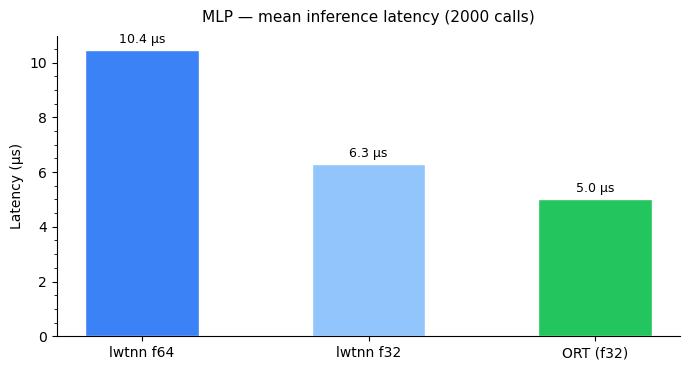

In [14]:
plot_latency_bar(
    mlp_bench_df,
    f"MLP — mean inference latency ({N_INFERENCES} calls)",
    colors=["#3b82f6", "#93c5fd", "#22c55e"],
)

---
## Summary — all backends and models

In [15]:
def kv_mean(kv): return float(kv["inference_mean_us"])
def kv_rss(kv):  return float(kv["peak_rss_kb"]) / 1024

summary_rows = [
    {"Model": "GRU (19f×20t)", "Backend": "lwtnn f64",      "Mean (µs)": kv_mean(gru_lwtnn_f64_kv),  "Peak RSS (MB)": kv_rss(gru_lwtnn_f64_kv)},
    {"Model": "GRU (19f×20t)", "Backend": "lwtnn f32",      "Mean (µs)": kv_mean(gru_lwtnn_f32_kv),  "Peak RSS (MB)": kv_rss(gru_lwtnn_f32_kv)},
    {"Model": "GRU (19f×20t)", "Backend": "ORT unrolled",   "Mean (µs)": kv_mean(gru_ort_unrolled_kv),"Peak RSS (MB)": kv_rss(gru_ort_unrolled_kv)},
    {"Model": "GRU (19f×20t)", "Backend": "ORT native GRU", "Mean (µs)": kv_mean(gru_ort_native_kv), "Peak RSS (MB)": kv_rss(gru_ort_native_kv)},
    {"Model": "MLP (60→…→8)", "Backend": "lwtnn f64",      "Mean (µs)": kv_mean(mlp_lwtnn_f64_kv),  "Peak RSS (MB)": kv_rss(mlp_lwtnn_f64_kv)},
    {"Model": "MLP (60→…→8)", "Backend": "lwtnn f32",      "Mean (µs)": kv_mean(mlp_lwtnn_f32_kv),  "Peak RSS (MB)": kv_rss(mlp_lwtnn_f32_kv)},
    {"Model": "MLP (60→…→8)", "Backend": "ORT (f32)",      "Mean (µs)": kv_mean(mlp_ort_kv),        "Peak RSS (MB)": kv_rss(mlp_ort_kv)},
]
summary_df = pd.DataFrame(summary_rows).set_index(["Model", "Backend"])
display(summary_df.style
        .format({"Mean (µs)": "{:.2f}", "Peak RSS (MB)": "{:.1f}"})
        .set_caption("Summary — mean latency and peak memory")
        .highlight_min(axis=0, subset=["Mean (µs)", "Peak RSS (MB)"], props="font-weight:bold"))

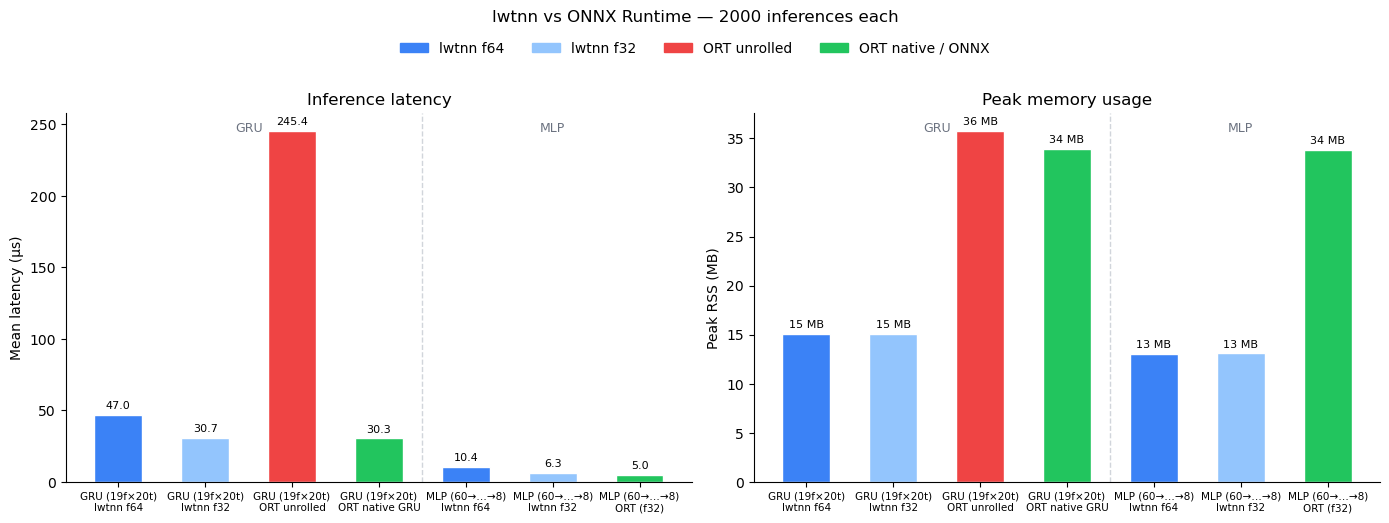

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

bar_colors = ["#3b82f6","#93c5fd","#ef4444","#22c55e",  # GRU group
              "#3b82f6","#93c5fd","#22c55e"]              # MLP group

labels = [f"{r['Model']}\n{r['Backend']}" for r in summary_rows]
latency = [r["Mean (µs)"]   for r in summary_rows]
rss     = [r["Peak RSS (MB)"] for r in summary_rows]

for ax, vals, ylabel, title, fmt in [
    (axes[0], latency, "Mean latency (µs)",  "Inference latency",  "%.1f"),
    (axes[1], rss,     "Peak RSS (MB)",       "Peak memory usage",  "%.0f MB"),
]:
    bars = ax.bar(range(len(summary_rows)), vals, color=bar_colors, width=0.55, edgecolor="white")
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=8)
    ax.set_xticks(range(len(summary_rows)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    # divider between GRU and MLP groups
    ax.axvline(3.5, color="#d1d5db", linewidth=1, linestyle="--")
    ax.text(1.5, ax.get_ylim()[1]*0.95, "GRU", ha="center", fontsize=9, color="#6b7280")
    ax.text(5.0, ax.get_ylim()[1]*0.95, "MLP", ha="center", fontsize=9, color="#6b7280")

from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#3b82f6", label="lwtnn f64"),
    Patch(color="#93c5fd", label="lwtnn f32"),
    Patch(color="#ef4444", label="ORT unrolled"),
    Patch(color="#22c55e", label="ORT native / ONNX"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 1.04), frameon=False)
plt.suptitle(f"lwtnn vs ONNX Runtime — {N_INFERENCES} inferences each", y=1.08, fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
import shutil
shutil.rmtree(gru_tmpdir, ignore_errors=True)
shutil.rmtree(mlp_tmpdir, ignore_errors=True)
print("Temp files cleaned up.")

Temp files cleaned up.
